
# GCLF Reach Analysis

Repository: <a href="https://github.com/Pommers/gc_surveys_telescope">github.com/Pommers/gc_surveys_telescope</a> <br>

# GCLF Reach Analysis Notebook

## Purpose

This notebook performs an analysis on 8 contemporary observatory setups for GC survey capability. It will

1. Load the initial instrument parameters `csv`.
2. Setup defensible 
3. Add GC angular-size calculation
4. Normalize Band-passes for instruments
5. Add filter-specific columns
6. Save initial instrument analysis file


In [1]:

from pathlib import Path
import sys
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

def find_project_root(marker="src"):
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(
        f"Could not find project root containing '{marker}'"
    )

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
INTERMEDIATE_DIR = DATA_DIR / "intermediate"
# CATALOGUE_DIR = DATA_DIR / "catalogues" / "detection"
FIGURE_DIR = PROJECT_ROOT / "figures" 
CONFIG_DIR = PROJECT_ROOT / "config"

# CATALOGUE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

from src.io_utils import setup_logging, load_config

setup_logging(verbose=True, name="Coma_GCs_survey")
logger = logging.getLogger("Coma_GCs_survey")

config = load_config(PROJECT_ROOT)

logger.info("Project root: %s", PROJECT_ROOT)
# logger.info("Catalogue directory: %s", CATALOGUE_DIR)
logger.info("Figure directory: %s", FIGURE_DIR)


Project root: /Users/richard/PycharmProjects/gc_surveys_telescope
Figure directory: /Users/richard/PycharmProjects/gc_surveys_telescope/figures


# Load the `inst.csv` file

In [2]:

inst = pd.read_csv(
    INTERMEDIATE_DIR / "instrument_parameters_v1.csv"
)

inst

,facility,instrument,regime,observing_mode,status,aperture_m,fov_width_arcsec,fov_height_arcsec,fov_area_deg2,pixel_scale_arcsec,...,D90_mpc,gc_rh_arcsec_100mpc,gc_resolution_ratio_100mpc,D_gc_rh_equals_psf_mpc,gc_filter_lambda_eff_um,gc_filter_lambda_min_um,gc_filter_lambda_max_um,gc_filter_basis,parameter_version,filter_values_status
0,HST,ACS/WFC,targeted_space,directed,operational,2.4,202.0,202.0,0.003148,0.049,...,NaN,0.006188,0.068757,6.875688,0.8060,0.730,0.880,published pivot + approximate broadband limits,v1_firstpass,first_pass
1,JWST,NIRCam SW,targeted_space,directed,operational,6.5,NaN,NaN,0.002694,0.031,...,NaN,0.006188,0.123762,12.376238,1.5010,1.331,1.668,STScI commissioning total-system throughput,v1_firstpass,first_pass
2,Subaru,HSC,wide_ground,survey+directed,operational,8.2,5400.0,5400.0,1.767146,0.168,...,NaN,0.006188,0.010314,1.031353,0.7700,0.700,0.850,HSC published filter curve; first-pass limits,v1_firstpass,first_pass
3,Rubin,LSSTCam,wide_ground,survey,operational,8.4,NaN,NaN,9.600000,0.200,...,NaN,0.006188,0.008840,0.884017,0.7500,0.690,0.820,LSST total-system band approximation,v1_firstpass,first_pass
4,Euclid,VIS,wide_space,survey,operational,1.2,NaN,NaN,0.540000,0.100,...,NaN,0.006188,0.034378,3.437844,0.7200,0.550,0.900,Euclid VIS nominal broad passband,v1_firstpass,first_pass
5,Roman,WFI,wide_space,survey+directed,forthcoming,2.4,NaN,NaN,0.281000,0.110,...,NaN,0.006188,NaN,NaN,0.8696,0.795,0.944,Roman WFI pivot and FWHM,v1_firstpass,first_pass
6,ELT,MICADO + MORFEO,elt_ao,directed,planned,39.0,50.5,50.5,0.000197,0.004,...,NaN,0.006188,NaN,NaN,1.2500,1.150,1.350,standard J-band approximation,v1_firstpass,first_pass
7,TMT,IRIS + NFIRAOS,elt_ao,directed,planned,30.0,34.0,34.0,0.000089,0.004,...,NaN,0.006188,NaN,NaN,1.2500,1.150,1.350,standard J-band approximation,v1_firstpass,first_pass


# Calculate $M_\mathrm{GCLF,TO}$

## Determine $I$-band Corrections

For $M_\mathrm{GCLF,TO}$, we initially start from the empirical $I$-band anchor at

$$M^\mathrm{TO}_I\approx−8.46$$

and transform away from $I$ using a single old-GC population assumption, rather than mixing unrelated turnover measurements from different galaxies. Kundu & Whitmore give the optical anchor, while empirical optical–NIR GC work shows that old clusters are well reproduced by SSP models in this regime [(e.g., Bruzual & Charlot., 2003](https://ui.adsabs.harvard.edu/abs/2003MNRAS.344.1000B/abstract); [Pessev et al., 2008)](https://ui.adsabs.harvard.edu/abs/2008MNRAS.385.1535P/abstract)

As we are looking at different regimes (e.g., directed, survey) we should add this to the GCLF determination ...

In [3]:
inst["M_gclf_to"] = np.nan
inst["M_gclf_to_basis"] = ""


and treat the facilities in three groups


In [4]:
# First-pass grouping only

optical_I_like = ["HST", "Subaru", "Rubin", "Euclid", "Roman"]
near_ir = ["ELT", "TMT"]
deep_nir = ["JWST"]


For the optical group, we can reasonably start very close to the empirical $I$-band turnover and then refine the small filter offsets later.

For $J$ and $\mathrm{F150W}$, we should not guess a correction blindly. There is empirical optical–NIR work on old GCs, including [Pessev et al. (2008)](https://ui.adsabs.harvard.edu/abs/2008MNRAS.385.1535P/abstract) and [Blakeslee et al. (2012)](https://ui.adsabs.harvard.edu/abs/2012ApJ...746...88B/abstract); importantly, Pessev et al. find that standard SSP models reproduce the integrated colors of $>10$ Gyr clusters reasonably well. That gives us a defensible route to an $I-J$ and $I-\mathrm{F150W}$ correction.

So, in practical terms, we create a dataframe with all the info needed for the gclf model

In [5]:
gclf_band_model = pd.DataFrame({
    "facility": inst["facility"],
    "filter": inst["gc_filter"],
    "lambda_eff_um": inst["gc_filter_lambda_eff_um"],
    "M_to_ab": np.nan,
    "delta_from_I": np.nan,
    "basis": ""
})


then populate the optical filters first - **Note - ONLY for exploratory plot!** - Euclid $\mathrm{VIS}$ and Roman $\mathrm{F087}$ are approximated as $I$-like.

In [6]:
# define GCLF TO in I-filter band for optical
M_TO_I = -8.46

approx_optical = {
    "HST":    0.00,
    "Subaru": 0.00,
    "Rubin":  0.00,
    "Euclid": 0.00,
    "Roman":  0.00,
}

for facility, delta in approx_optical.items():
    mask = gclf_band_model["facility"] == facility

    gclf_band_model.loc[mask, "delta_from_I"] = delta
    gclf_band_model.loc[mask, "M_to_ab"] = M_TO_I + delta
    gclf_band_model.loc[mask, "basis"] = "first-pass I-like approximation"

gclf_band_model

,facility,filter,lambda_eff_um,M_to_ab,delta_from_I,basis
0,HST,F814W,0.8060,-8.46,0.0,first-pass I-like approximation
1,JWST,F150W,1.5010,NaN,NaN,
2,Subaru,i2,0.7700,-8.46,0.0,first-pass I-like approximation
3,Rubin,i,0.7500,-8.46,0.0,first-pass I-like approximation
4,Euclid,VIS,0.7200,-8.46,0.0,first-pass I-like approximation
5,Roman,F087,0.8696,-8.46,0.0,first-pass I-like approximation
6,ELT,J,1.2500,NaN,NaN,
7,TMT,J,1.2500,NaN,NaN,


Pessev et al. is useful as an empirical validation paper: it gives integrated 2MASS $JHK_s$ photometry for Magellanic Cloud clusters and composite colors such as $V−J$, $V−K_s$, and $J−K_s$, and shows that several SSP models reproduce the colors of old $>10$ Gyr clusters reasonably well. But it does not give us the clean $I−J$ or $\mathrm{F814W}–\mathrm{F150W}$ transformation we actually want, and its photometry is in the 2MASS/Vega system. So we'd immediately be doing extra conversions and mixing systems.

There is newer empirical work — including actual JWST observations of old GCs. [Nardiello et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022MNRAS.517..484N/abstract) obtained F090W/F150W photometry of M92, and [Milone et al. (2023)](https://ui.adsabs.harvard.edu/abs/2023MNRAS.522.2429M/abstract) modeled old GC stars directly in NIRCam filters. Even more directly relevant to our extragalactic problem, [Berkheimer et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024ApJ...964L..29B/abstract) used $\mathrm{F090W}/\mathrm{F150W}$ GC photometry around VV 191a; their models imply a GC luminosity-function peak around $M_\mathrm{AB}\sim−9.4\pm0.2$ in $\mathrm{F090W}$, although their data do not quite reach the turnover. And work from our friend William [Harris et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025ApJ...993..210H/abstract) has explicit evaluated NIRCam filters for GC systems over redshift.


So, a cleaner modern methodology for this paper would be

>Anchor the GCLF turnover mass/luminosity empirically in F814W, then use one modern SSP SED to calculate synthetic AB colors in all eight adopted passbands.

In other words, rather than saying

$$M_J^\mathrm{TO}=M_I^\mathrm{TO}−(I−J)_\mathrm{Pessev},$$

we calculate

$$\Delta_X=m_X^\mathrm{SSP}−m_\mathrm{F814W}^\mathrm{SSP}$$

for a representative old GC, and then

$$M_X^\mathrm{TO}=−8.46+\Delta_X.$$

That automatically handles $\mathrm{F150W}, \mathrm{F087}$, Euclid VIS, Rubin $i$, etc., rather than trying to find empirical transformations for every modern filter.

## What SSP?

For a quick first pass, FSPS + MIST looks very attractive. Modern published work routinely uses FSPS with MIST isochrones and synthetic photometry in both HST/ACS and JWST/NIRCam filters; [e.g., Wan et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024MNRAS.532.4002W/abstract) explicitly generate $\mathrm{F814W}$ and $\mathrm{F150W}$ photometry this way.

So the way forward is to choose a simple representative population like

- age_gyr = 12.0
- feh = -1.0

but later we can repeat with variations

- age_gyr = [10, 12, 13]
- feh = [-1.5, -1.0, -0.5]

and the exact mass normalization cancels in the color transformation. We don't need to know the SSP's absolute mass yet; we only need its relative flux between F814W and the target passband.

Pessev et al. becomes a nice supporting citation saying old-cluster optical–NIR colors are empirically reasonably reproduced by SSPs, rather than being responsible for the numerical conversion.



## Set up the minimal FSPS/MIST calculation

Attempt to get F814W → J/F150W offsets

FSPS can give us a 12-Gyr SSP spectrum directly in $L_\odot/\mathrm{Hz}$, with MIST available in the standard setup, and we can integrate that spectrum through our first-pass top-hat bandpasses using the min/max wavelengths we already stored. That keeps everything internally consistent and gets us to $M_\mathrm{TO} today. FSPS documents `StellarPopulation`, `get_spectrum()`, and AB-magnitude generation directly.

In [7]:
# import fsps

# sp = fsps.StellarPopulation()


In [8]:
# sp = fsps.StellarPopulation(
#     compute_vega_mags=False,   # AB system
#     zcontinuous=1,
#     sfh=0,                     # SSP
#     logzsol=-1.0,              # first-pass old GC metallicity
#     add_neb_emission=False,
#     add_dust_emission=False,
# )

# print(sp.libraries)

buuuuutt...

this requires a full SPS_HOME/model-data setup, so in the first instance I'll go with some defensible values to do some first pass work.

# First pass - defensible values!

For a first-pass we can use two empirical NIR anchors rather than fight the SPS software...!

- J-band: [Wang et al. (2014)](https://ui.adsabs.harvard.edu/abs/2014arXiv1404.4444W/abstract) measure an M31 GC GCLF peak at $J_0=15.348_{−0.208}^{+0.206}$ in 2MASS $J$. Using the 2MASS $J$ zero-point of 1594 Jy gives $J_\mathrm{AB}−J_\mathrm{Vega}≃0.91$ mag. With the standard M31 distance modulus $\mu\simeq24.47$, this corresponds to roughly

$$M_{J,\mathrm{AB}}^\mathrm{TO}\simeq−8.21.$$

- $\mathrm{F150W}$: recent JWST GC work [(e.g., Keatley & Harris, 2025)](https://ui.adsabs.harvard.edu/abs/2025ApJ...990...67K/abstract) quotes an expected turnover around $M_\mathrm{F150W}\simeq−8.3\ \mathrm{AB}$.

This is pleasantly consistent, because the NIR turnover in $\mathrm{AB}$ magnitudes is not dramatically brighter than $\mathrm{F814W}$. The huge Vega-system $I−J$ colors mostly disappear once both bands are expressed in $\mathrm{AB}$.

In [9]:
M_TO_F814W = -8.46

firstpass_Mto = {
    "HST":    -8.46,  # F814W empirical anchor
    "JWST":   -8.30,  # F150W, literature first-pass
    "Subaru": -8.46,  # i2 ~ I-like approximation
    "Rubin":  -8.46,  # i ~ I-like approximation
    "Euclid": -8.46,  # broad VIS; provisional
    "Roman":  -8.46,  # F087 ~ I/z-like; provisional
    "ELT":    -8.21,  # J, empirical M31-based estimate
    "TMT":    -8.21,  # same J-band assumption
}

# flag the basis of the above values
firstpass_basis = {
    "HST":    "empirical F814W GCLF anchor",
    "JWST":   "literature F150W turnover approximation",
    "Subaru": "F814W-equivalent first-pass approximation",
    "Rubin":  "F814W-equivalent first-pass approximation",
    "Euclid": "F814W-equivalent first-pass approximation",
    "Roman":  "F814W-equivalent first-pass approximation",
    "ELT":    "2MASS J GCLF; M31 empirical estimate converted to AB",
    "TMT":    "2MASS J GCLF; M31 empirical estimate converted to AB",
}


Update the table...

In [10]:
for facility, Mto in firstpass_Mto.items():
    mask = gclf_band_model["facility"] == facility

    gclf_band_model.loc[mask, "M_to_ab"] = Mto
    gclf_band_model.loc[mask, "delta_from_F814W"] = (
        Mto - M_TO_F814W
    )
    gclf_band_model.loc[mask, "basis"] = firstpass_basis[facility]

gclf_band_model["M_to_uncertainty_mag"] = 0.20

gclf_band_model

,facility,filter,lambda_eff_um,M_to_ab,delta_from_I,basis,delta_from_F814W,M_to_uncertainty_mag
0,HST,F814W,0.8060,-8.46,0.0,empirical F814W GCLF anchor,0.00,0.2
1,JWST,F150W,1.5010,-8.30,NaN,literature F150W turnover approximation,0.16,0.2
2,Subaru,i2,0.7700,-8.46,0.0,F814W-equivalent first-pass approximation,0.00,0.2
3,Rubin,i,0.7500,-8.46,0.0,F814W-equivalent first-pass approximation,0.00,0.2
4,Euclid,VIS,0.7200,-8.46,0.0,F814W-equivalent first-pass approximation,0.00,0.2
5,Roman,F087,0.8696,-8.46,0.0,F814W-equivalent first-pass approximation,0.00,0.2
6,ELT,J,1.2500,-8.21,NaN,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2
7,TMT,J,1.2500,-8.21,NaN,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2


In [11]:
gclf_band_model = gclf_band_model.drop(
    columns=["delta_from_I"],
    errors="ignore"
)

gclf_band_model.loc[
    gclf_band_model["facility"] == "HST",
    "M_to_uncertainty_mag"
] = 0.10

gclf_band_model

,facility,filter,lambda_eff_um,M_to_ab,basis,delta_from_F814W,M_to_uncertainty_mag
0,HST,F814W,0.8060,-8.46,empirical F814W GCLF anchor,0.00,0.1
1,JWST,F150W,1.5010,-8.30,literature F150W turnover approximation,0.16,0.2
2,Subaru,i2,0.7700,-8.46,F814W-equivalent first-pass approximation,0.00,0.2
3,Rubin,i,0.7500,-8.46,F814W-equivalent first-pass approximation,0.00,0.2
4,Euclid,VIS,0.7200,-8.46,F814W-equivalent first-pass approximation,0.00,0.2
5,Roman,F087,0.8696,-8.46,F814W-equivalent first-pass approximation,0.00,0.2
6,ELT,J,1.2500,-8.21,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2
7,TMT,J,1.2500,-8.21,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2


# Save interim `CSV`

In [12]:
gclf_band_model.to_csv(
    INTERMEDIATE_DIR / "gclf_band_model_v1.csv",
    index=False
)


# Create a depth table

## Standardized depths
For the depth side, we need to do this in a way that keeps the actual survey depths and the standardized/direct-observation depths separate.

For the first-pass plot, I'm thinking populate the survey facilities with published $5\sigma$ point-source depths in our adopted band wherever possible:

### HST/ACS
[Koekemoer et al. (2007)](https://ui.adsabs.harvard.edu/abs/2007ApJS..172..196K/abstract)

For HST, COSMOS is a very useful empirical standardization: one ACS/WFC F814W orbit, 2028 s, reached AB(F814W)=27.2 at 5σ. That is almost exactly the sort of “directed exposure benchmark” we wanted.

### Subaru/HSC
[Aihara et al. (2018)](https://ui.adsabs.harvard.edu/abs/2018PASJ...70S...8A/abstract)

For HSC, the first public HSC-SSP data reached $i∼26.4$ AB at $5\sigma$ for point sources, with $\sim0.6^{''}$ $i$-band seeing.

### Rubin
[Vera C. Rubin Observatory Team (2026)](https://ui.adsabs.harvard.edu/abs/2026AJ....171..360V/abstract)

For Rubin, there is a nice 2026 published comparison: the expected 10-year i-band coadd is 26.34 AB at 5σ. This is actually a little shallower than the old rough “27.5” number because that latter headline is usually r-band.

### Euclid
[Yang et al. (2026)](https://ui.adsabs.harvard.edu/abs/2026A%26A...711A.104Y/abstract)

Euclid is the odd one because its quoted Wide depth is $10\sigma$, not $5\sigma$. So we should either retain survey_depth_snr=10 and use it consistently, or convert it to an approximate equivalent $5\sigma$ limit. So, retaining the native value for now rather than manufacture a transformed number. The VIS Wide requirement is $m_{AB}>24.5$ at S/N >10.

### Roman
[Karmen et al. (2026)](https://ui.adsabs.harvard.edu/abs/2026ApJ..1006...20K/abstract)

Roman is more survey-dependent. A recent Roman calculation using the mission ETC and HLTDS observing plan gives $\mathrm{F087} ≈ 25.05 \mathrm{AB}$ at $5\sigma$ per survey exposure configuration. So, here we'll mark that explicitly as an HLTDS representative depth, not a generic WFI limit.

### JWST/NIRCam
[Berkheimer et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024ApJ...964L..29B/abstract)

For JWST, published early NIRCam extragalactic work gives an $\mathrm{F150W} 5\sigma$ point-source limit of $28.24 \mathrm{AB}$ in one representative dataset. We’ll want to attach its exposure time before using it as a standardized 1-hour depth, but it’s already good enough as an empirical “real JWST imaging” anchor.


In [13]:
depth_model = pd.DataFrame([
    {
        "facility": "HST",
        "filter": "F814W",
        "depth_ab": 27.20,
        "snr": 5.0,
        "exposure_s": 2028.0,
        "depth_type": "directed_empirical",
        "basis": "COSMOS ACS/WFC F814W"
    },
    {
        "facility": "JWST",
        "filter": "F150W",
        "depth_ab": 28.24,
        "snr": 5.0,
        "exposure_s": np.nan,   # fill when we pin down dataset exposure
        "depth_type": "directed_empirical",
        "basis": "published NIRCam point-source depth"
    },
    {
        "facility": "Subaru",
        "filter": "i2",
        "depth_ab": 26.40,
        "snr": 5.0,
        "exposure_s": np.nan,
        "depth_type": "survey_coadd",
        "basis": "HSC-SSP Wide/PDR1"
    },
    {
        "facility": "Rubin",
        "filter": "i",
        "depth_ab": 26.34,
        "snr": 5.0,
        "exposure_s": np.nan,
        "depth_type": "survey_coadd",
        "basis": "expected LSST 10-year coadd"
    },
    {
        "facility": "Euclid",
        "filter": "VIS",
        "depth_ab": 24.50,
        "snr": 10.0,
        "exposure_s": 4 * 565.0,
        "depth_type": "survey_coadd",
        "basis": "Euclid Wide VIS requirement"
    },
    {
        "facility": "Roman",
        "filter": "F087",
        "depth_ab": 25.05,
        "snr": 5.0,
        "exposure_s": np.nan,
        "depth_type": "survey_representative",
        "basis": "Roman HLTDS representative ETC depth"
    },
    {
        "facility": "ELT",
        "filter": "J",
        "depth_ab": np.nan,
        "snr": 5.0,
        "exposure_s": 3600.0,
        "depth_type": "predicted_1hr",
        "basis": "to populate from MICADO prediction"
    },
    {
        "facility": "TMT",
        "filter": "J",
        "depth_ab": np.nan,
        "snr": 5.0,
        "exposure_s": 3600.0,
        "depth_type": "predicted_1hr",
        "basis": "to populate from IRIS prediction"
    },
])

## Add in ELT/MICADO and TMT/IRIS

Include representative *predicted* $J$-band depths on comparable footings to the other facilites.

### ELT/MICADO
[Davies et al. (2010)](https://www.eso.org/sci/publications/messenger/archive/no.140-jun10/messenger-no140-32-33.pdf)
The published prediction from Davies et al. report that isolated point sources should reach better than $AB$ 30 at $5\sigma$ in one hour in $J$ and $H$. So we set...



In [14]:
MICADO_J_5SIG_1HR = 30.0


### TMT/IRIS
[Moore et al. (2014)](https://ui.adsabs.harvard.edu/abs/2014SPIE.9147E..24M/abstract)

For TMT/IRIS, the cleanest published number is a little different: the IRIS imaging sensitivity table gives $J_\mathrm{AB}=27.8$ for a 5-hour integration at S/N = 100, for the imager. That is much more stringent than our $5\sigma$ criterion, so we can convert it.

In the background-limited regime, 

$$m_2−m_1=2.5 \log_{10} \left[\frac{(\mathrm{S/N})_1}{(\mathrm{S/N})_2}\sqrt{\frac{t_2}{t_1}}\right].$$

So converting $27.8 \mathrm{AB}$ at S/N 100 in 5 h to $5\sigma$ in 1 h gives us


In [15]:
m_tmt_1hr_5sig = (
    27.8
    + 2.5 * np.log10(
        (100 / 5) * np.sqrt(1 / 5)
    )
)

print(m_tmt_1hr_5sig)


30.17886248373993


So now set the depths for the ELT facilities

In [16]:
elt_depths = {
    "ELT": {
        "filter": "J",
        "depth_ab": MICADO_J_5SIG_1HR,
        "snr": 5.0,
        "exposure_s": 3600.0,
        "depth_type": "predicted_1hr",
        "basis": "MICADO predicted J-band 5sigma sensitivity"
    },

    "TMT": {
        "filter": "J",
        "depth_ab": m_tmt_1hr_5sig,
        "snr": 5.0,
        "exposure_s": 3600.0,
        "depth_type": "predicted_1hr_scaled",
        "basis": "IRIS J=27.8 AB at S/N=100 in 5h, scaled to 5sigma 1h"
    },
}

In [17]:
for facility, vals in elt_depths.items():

    mask = depth_model["facility"] == facility

    for col, value in vals.items():
        if col != "filter":
            depth_model.loc[mask, col] = value



## Merge with the GCLF turnover table


In [18]:
reach = (
    gclf_band_model
    .merge(
        depth_model,
        on=["facility", "filter"],
        how="left"
    )
)

reach

,facility,filter,lambda_eff_um,M_to_ab,basis_x,delta_from_F814W,M_to_uncertainty_mag,depth_ab,snr,exposure_s,depth_type,basis_y
0,HST,F814W,0.8060,-8.46,empirical F814W GCLF anchor,0.00,0.1,27.200000,5.0,2028.0,directed_empirical,COSMOS ACS/WFC F814W
1,JWST,F150W,1.5010,-8.30,literature F150W turnover approximation,0.16,0.2,28.240000,5.0,NaN,directed_empirical,published NIRCam point-source depth
2,Subaru,i2,0.7700,-8.46,F814W-equivalent first-pass approximation,0.00,0.2,26.400000,5.0,NaN,survey_coadd,HSC-SSP Wide/PDR1
3,Rubin,i,0.7500,-8.46,F814W-equivalent first-pass approximation,0.00,0.2,26.340000,5.0,NaN,survey_coadd,expected LSST 10-year coadd
4,Euclid,VIS,0.7200,-8.46,F814W-equivalent first-pass approximation,0.00,0.2,24.500000,10.0,2260.0,survey_coadd,Euclid Wide VIS requirement
5,Roman,F087,0.8696,-8.46,F814W-equivalent first-pass approximation,0.00,0.2,25.050000,5.0,NaN,survey_representative,Roman HLTDS representative ETC depth
6,ELT,J,1.2500,-8.21,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2,30.000000,5.0,3600.0,predicted_1hr,MICADO predicted J-band 5sigma sensitivity
7,TMT,J,1.2500,-8.21,2MASS J GCLF; M31 empirical estimate converted...,0.25,0.2,30.178862,5.0,3600.0,predicted_1hr_scaled,"IRIS J=27.8 AB at S/N=100 in 5h, scaled to 5si..."


# Calculate the first reach values

In [19]:
from scipy.stats import norm

SIGMA_GCLF = 1.40

def gclf_reach_mpc(m_lim, M_to, fraction, sigma=SIGMA_GCLF):
    if pd.isna(m_lim) or pd.isna(M_to):
        return np.nan

    M_fraction = M_to + sigma * norm.ppf(fraction)
    mu = m_lim - M_fraction

    return 10**((mu - 25.0) / 5.0)


for f, label in [
    (0.10, "D10_mpc"),
    (0.50, "D50_mpc"),
    (0.90, "D90_mpc"),
]:
    reach[label] = reach.apply(
        lambda row: gclf_reach_mpc(
            row["depth_ab"],
            row["M_to_ab"],
            f
        ),
        axis=1
    )

In [20]:
reach[
    [
        "facility", "filter",
        "M_to_ab", "depth_ab", "snr",
        "D10_mpc", "D50_mpc", "D90_mpc"
    ]
]

,facility,filter,M_to_ab,depth_ab,snr,D10_mpc,D50_mpc,D90_mpc
0,HST,F814W,-8.46,27.200000,5.0,309.623873,135.518941,59.315140
1,JWST,F150W,-8.30,28.240000,5.0,464.338227,203.235701,88.954016
2,Subaru,i2,-8.46,26.400000,5.0,214.207384,93.756201,41.036051
3,Rubin,i,-8.46,26.340000,5.0,208.369639,91.201084,39.917705
4,Euclid,VIS,-8.46,24.500000,10.0,89.296500,39.084090,17.106673
5,Roman,F087,-8.46,25.050000,5.0,115.036176,50.350061,22.037664
6,ELT,J,-8.21,30.000000,5.0,1001.923212,438.530698,191.940031
7,TMT,J,-8.21,30.178862,5.0,1087.944986,476.181476,208.419360


## Normalize the S/N convention

In [21]:
def depth_at_target_snr(depth_ab, native_snr, target_snr=5.0):
    return depth_ab + 2.5 * np.log10(native_snr / target_snr)

reach["depth_5sigma_ab"] = reach.apply(
    lambda row: depth_at_target_snr(
        row["depth_ab"],
        row["snr"],
        target_snr=5.0
    ),
    axis=1
)

Rerun reach calculation with all $5\sigma$ values

In [22]:
for f, label in [
    (0.10, "D10_mpc"),
    (0.50, "D50_mpc"),
    (0.90, "D90_mpc"),
]:
    reach[label] = reach.apply(
        lambda row: gclf_reach_mpc(
            row["depth_5sigma_ab"],
            row["M_to_ab"],
            f
        ),
        axis=1
    )

In [23]:
reach[
    [
        "facility", "filter",
        "M_to_ab", "depth_5sigma_ab", "snr",
        "D10_mpc", "D50_mpc", "D90_mpc"
    ]
]


,facility,filter,M_to_ab,depth_5sigma_ab,snr,D10_mpc,D50_mpc,D90_mpc
0,HST,F814W,-8.46,27.200000,5.0,309.623873,135.518941,59.315140
1,JWST,F150W,-8.30,28.240000,5.0,464.338227,203.235701,88.954016
2,Subaru,i2,-8.46,26.400000,5.0,214.207384,93.756201,41.036051
3,Rubin,i,-8.46,26.340000,5.0,208.369639,91.201084,39.917705
4,Euclid,VIS,-8.46,25.252575,10.0,126.284322,55.273250,24.192489
5,Roman,F087,-8.46,25.050000,5.0,115.036176,50.350061,22.037664
6,ELT,J,-8.21,30.000000,5.0,1001.923212,438.530698,191.940031
7,TMT,J,-8.21,30.178862,5.0,1087.944986,476.181476,208.419360


# First Figure

## Recovered GCLF fraction versus distance

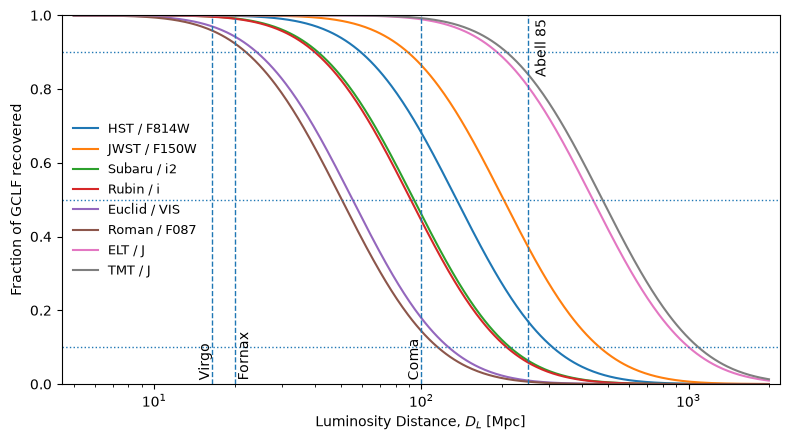

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def recovered_fraction(distance_mpc, m_lim, M_to, sigma=1.4):
    mu = 5 * np.log10(distance_mpc) + 25
    M_lim = m_lim - mu
    return norm.cdf((M_lim - M_to) / sigma)

dist = np.logspace(
    np.log10(5),
    np.log10(2000),
    500
)

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.set_title("Recovered GCLF fraction vs. distance")

for _, row in reach.iterrows():

    if pd.isna(row["depth_5sigma_ab"]):
        continue

    f = recovered_fraction(
        dist,
        row["depth_5sigma_ab"],
        row["M_to_ab"],
        sigma=1.4
    )

    ax.plot(
        dist,
        f,
        label=f'{row["facility"]} / {row["filter"]}'
    )

ax.set_xscale("log")
ax.set_xlim(4.5, 2200)
ax.set_ylim(0, 1)

ax.set_xlabel(r"Luminosity Distance, $D_L$ [Mpc]")
ax.set_ylabel("Fraction of GCLF recovered")

ax.axhline(0.1, ls=":", lw=1)
ax.axhline(0.5, ls=":", lw=1)
ax.axhline(0.9, ls=":", lw=1)

# Useful distance anchors
ax.axvline(16.5, ls="--", lw=1)
ax.axvline(20.0, ls="--", lw=1)
ax.axvline(100.0, ls="--", lw=1)
ax.axvline(250.0, ls="--", lw=1)

ax.text(16.5, 0.01, "Virgo", rotation=90,
        va="bottom", ha="right")
ax.text(20.5, 0.01, "Fornax", rotation=90,
        va="bottom", ha="left")
ax.text(100.0, 0.01, "Coma", rotation=90,
        va="bottom", ha="right")
ax.text(265, 0.99, "Abell 85", rotation=90,
        va="top", ha="left")

ax.legend(frameon=False, fontsize=9, loc='center left')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "recovered_gclf.png", bbox_inches='tight', format='png', dpi=200)
plt.show()



**Figure 1 — GCLF recovery with distance**

Fraction of the globular cluster luminosity function (GCLF) recovered as a function of luminosity distance for representative current and future observing facilities. Curves assume a Gaussian GCLF with the adopted band-dependent turnover magnitudes and $\sigma_\mathrm{GCLF}=1.4~\mathrm{mag}$, together with representative $5\sigma$ point-source depths for each observing configuration. Horizontal dotted lines mark 10\%, 50\%, and 90\% recovery, while vertical dashed lines indicate the approximate luminosity distances of Virgo, Fornax, Coma, and Abell 85. The figure illustrates that the effective reach of a GC survey depends strongly on the fraction of the underlying GCLF that must be sampled; detection of the bright tail can extend substantially farther than representative sampling near or below the turnover.

# Derive FOV for facility/configuration

A simple next derived quantity is physical FoV area at distance $D$:

$$A_\mathrm{phys}(D)=\Omega_\mathrm{FoV}D_A^2,$$

or for a low-$z$ first pass, using small-angle geometry, i.e.,


In [25]:
def fov_area_kpc2(distance_mpc, fov_area_deg2):
    arcsec2 = fov_area_deg2 * 3600**2
    pc_per_arcsec = 4.848 * distance_mpc
    return arcsec2 * pc_per_arcsec**2 / 1e6

In [26]:
for D in [16.5, 20, 100, 250]:
    inst[f"fov_area_kpc2_{D}mpc"] = inst["fov_area_deg2"].apply(
        lambda a: fov_area_kpc2(D, a)
    )

In [27]:
inst

,facility,instrument,regime,observing_mode,status,aperture_m,fov_width_arcsec,fov_height_arcsec,fov_area_deg2,pixel_scale_arcsec,...,gc_filter_lambda_min_um,gc_filter_lambda_max_um,gc_filter_basis,parameter_version,filter_values_status,M_gclf_to_basis,fov_area_kpc2_16.5mpc,fov_area_kpc2_20mpc,fov_area_kpc2_100mpc,fov_area_kpc2_250mpc
0,HST,ACS/WFC,targeted_space,directed,operational,2.4,202.0,202.0,0.003148,0.049,...,0.730,0.880,published pivot + approximate broadband limits,v1_firstpass,first_pass,,261.093373,3.836083e+02,9.590207e+03,5.993879e+04
1,JWST,NIRCam SW,targeted_space,directed,operational,6.5,NaN,NaN,0.002694,0.031,...,1.331,1.668,STScI commissioning total-system throughput,v1_firstpass,first_pass,,223.443305,3.282914e+02,8.207284e+03,5.129552e+04
2,Subaru,HSC,wide_ground,survey+directed,operational,8.2,5400.0,5400.0,1.767146,0.168,...,0.700,0.850,HSC published filter curve; first-pass limits,v1_firstpass,first_pass,,146544.833482,2.153092e+05,5.382730e+06,3.364206e+07
3,Rubin,LSSTCam,wide_ground,survey,operational,8.4,NaN,NaN,9.600000,0.200,...,0.690,0.820,LSST total-system band approximation,v1_firstpass,first_pass,,796103.155483,1.169665e+06,2.924162e+07,1.827601e+08
4,Euclid,VIS,wide_space,survey,operational,1.2,NaN,NaN,0.540000,0.100,...,0.550,0.900,Euclid VIS nominal broad passband,v1_firstpass,first_pass,,44780.802496,6.579365e+04,1.644841e+06,1.028026e+07
5,Roman,WFI,wide_space,survey+directed,forthcoming,2.4,NaN,NaN,0.281000,0.110,...,0.795,0.944,Roman WFI pivot and FWHM,v1_firstpass,first_pass,,23302.602780,3.423707e+04,8.559266e+05,5.349542e+06
6,ELT,MICADO + MORFEO,elt_ao,directed,planned,39.0,50.5,50.5,0.000197,0.004,...,1.150,1.350,standard J-band approximation,v1_firstpass,first_pass,,16.318336,2.397552e+01,5.993879e+02,3.746174e+03
7,TMT,IRIS + NFIRAOS,elt_ao,directed,planned,30.0,34.0,34.0,0.000089,0.004,...,1.150,1.350,standard J-band approximation,v1_firstpass,first_pass,,7.396920,1.086784e+01,2.716959e+02,1.698099e+03


In [28]:
inst[['facility', 'instrument','fov_area_kpc2_16.5mpc','fov_area_kpc2_20mpc','fov_area_kpc2_100mpc', 'fov_area_kpc2_250mpc']]

,facility,instrument,fov_area_kpc2_16.5mpc,fov_area_kpc2_20mpc,fov_area_kpc2_100mpc,fov_area_kpc2_250mpc
0,HST,ACS/WFC,261.093373,3.836083e+02,9.590207e+03,5.993879e+04
1,JWST,NIRCam SW,223.443305,3.282914e+02,8.207284e+03,5.129552e+04
2,Subaru,HSC,146544.833482,2.153092e+05,5.382730e+06,3.364206e+07
3,Rubin,LSSTCam,796103.155483,1.169665e+06,2.924162e+07,1.827601e+08
4,Euclid,VIS,44780.802496,6.579365e+04,1.644841e+06,1.028026e+07
5,Roman,WFI,23302.602780,3.423707e+04,8.559266e+05,5.349542e+06
6,ELT,MICADO + MORFEO,16.318336,2.397552e+01,5.993879e+02,3.746174e+03
7,TMT,IRIS + NFIRAOS,7.396920,1.086784e+01,2.716959e+02,1.698099e+03


This shows the other side of the coin. For example, Rubin covers about 49,000 times the physical area of MICADO per pointing at the same distance, while MICADO has dramatically greater GC-depth reach.

One refinement I need to consider before building the next metric: because the distant-cluster part of the paper is now explicitly cosmological, the physical FoV should really use angular-diameter distance $D_A$ rather than luminosity distance $D_L$. The current numbers use distance directly as though $D_A=D_L, which is fine for Virgo/Coma but becomes increasingly wrong around Abell 85 (250 Mpc) and beyond.

So, for the eventual calculation we should use

$$D_A=\frac{D_L}{(1+z)^2}.$$

Since the Figure above (figure 1?) uses $D_L$ for the GCLF magnitude calculation and since the next figure (Figure 2?) deals with projected physical area, we should ensure this distinction is actually explicit.


## Define the 'grasp'

For each facility and distance, we can define a quantity relating the area of the FoV and the fraction of GCLF recovered, e.g.,

$$\mathcal{G}_\mathrm{GC}(z)=A_\mathrm{FoV}(D_A(z))f_\mathrm{GCLF}(D_L(z))$$

where:

- $A_\mathrm{FoV}$ uses angular-diameter distance because it converts angular area to physical area;
- $f_\mathrm{GCLF}$ uses luminosity distance because it comes from the apparent-magnitude limit.

We can refer to as `gc_area_grasp_kpc2`.

Conceptually this is:

> physical area sampled per pointing, weighted by the fraction of the GCLF recoverable.

For the full redshift $D_A$ including :

In [29]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# Throughout this paper, we assume a flat Λ cold dark matter (CDM) cosmology consistent with the constraints from 
# Planck (Planck Collaboration et al. 2016); h = 0.677, Ωm = 0.307, ΩΛ = 1 − Ωm, and Ωb = 0.0486.

cosmo = FlatLambdaCDM(
    H0=67.7 * u.km / u.s / u.Mpc,
    Om0=0.307,
    Ob0=0.0486
)

z_grid = np.logspace(
    np.log10(0.00118),
    np.log10(0.37),
    1000
)

D_L_grid = cosmo.luminosity_distance(z_grid).to_value(u.Mpc)
D_A_grid = cosmo.angular_diameter_distance(z_grid).to_value(u.Mpc)

def physical_fov_area_kpc2(D_A_mpc, fov_area_deg2):

    arcsec2 = fov_area_deg2 * 3600**2

    pc_per_arcsec = 4.848 * D_A_mpc

    return (
        arcsec2 *
        pc_per_arcsec**2 /
        1e6
    )

def gc_area_grasp(
    distance_mpc,
    fov_area_deg2,
    m_lim,
    M_to,
    sigma=1.4
):
    area = physical_fov_area_kpc2(
        distance_mpc,
        fov_area_deg2
    )

    f_gc = recovered_fraction(
        distance_mpc,
        m_lim,
        M_to,
        sigma
    )

    return area, f_gc, area * f_gc



and so over the same distance grid as for the previous figure this would be...

In [30]:
dist = np.logspace(
    np.log10(5),
    np.log10(2000),
    500
)

grasp_rows = []


for _, row in reach.iterrows():

    facility = row["facility"]

    fov = inst.loc[
        inst["facility"] == facility,
        "fov_area_deg2"
    ].iloc[0]

    for z, D_L, D_A in zip(z_grid, D_L_grid, D_A_grid):

        f_gc = recovered_fraction(
            D_L,
            row["depth_5sigma_ab"],
            row["M_to_ab"]
        )

        area = physical_fov_area_kpc2(
            D_A,
            fov
        )

        grasp_rows.append({
            "facility": facility,
            "z": z,
            "D_L_mpc": D_L,
            "D_A_mpc": D_A,
            "gc_fraction": f_gc,
            "fov_area_kpc2": area,
            "gc_area_grasp_kpc2": area * f_gc,
        })

grasp = pd.DataFrame(grasp_rows)


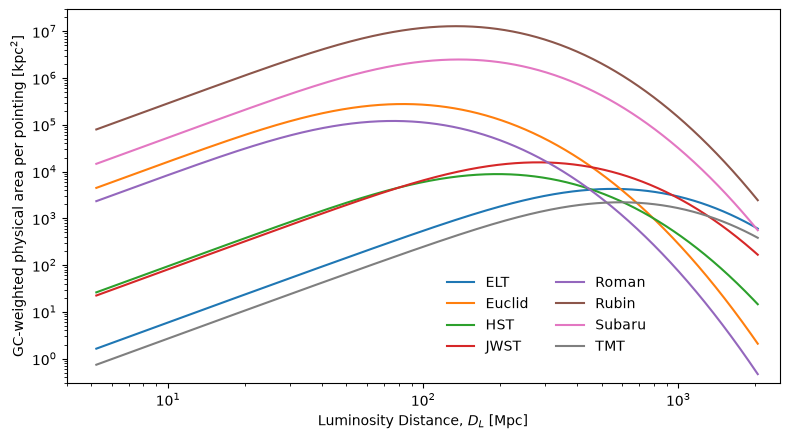

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.set_title(r"(New $D_A$) Area per pointing vs. Distance\n (Weighted by GCLF recovered fraction)")

for facility, sub in grasp.groupby("facility"):

    ax.plot(
        sub["D_L_mpc"],
        sub["gc_area_grasp_kpc2"],
        label=facility
    )

ax.set_xscale("log")
ax.set_xlim(4, 2500)
ax.set_yscale("log")
ax.set_ylim(0.3, 3e7)

ax.set_xlabel(r"Luminosity Distance, $D_L$ [Mpc]")
ax.set_ylabel(
    r"GC-weighted physical area per pointing [kpc$^2$]"
)

ax.legend(frameon=False, ncol=2, bbox_to_anchor=(0.83, 0.32),)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "gc_weighted_survey_area.png", bbox_inches='tight', format='png', dpi=200)

plt.show()


**Figure 2 — GC-weighted physical survey area**

GC-weighted physical area sampled per pointing as a function of luminosity distance, defined here as the projected physical field-of-view area multiplied by the fraction of the GCLF recovered at that distance. This metric combines point-source depth with instantaneous survey area and therefore emphasizes the complementarity between deep, narrow-field facilities and wide-field survey instruments. Each curve exhibits a maximum where the increasing physical area subtended by the field of view is balanced by declining GCLF recovery. In the adopted Euclidean first-pass model, this maximum occurs at a common recovered fraction of $\simeq24\%$ for $\sigma_\mathrm{GCLF}=1.4 \mathrm{mag}$, although the distance and absolute survey grasp at the maximum vary substantially between facilities.

So here the tables are flipped and the peaks are exactly the behavior we suspected might emerge.

What we’re seeing is the competition between

$$A_\mathrm{FoV}\propto D^2$$

and the rapidly declining recoverable GCLF fraction. At small distance, every pointing covers very little physical area even though the GCLF is essentially complete. At large distance, the physical area is enormous but completeness collapses. So each facility naturally develops a maximum GC-weighted survey grasp.

The numerical peaks for each facility are...

In [32]:
peak_grasp = (
    grasp.loc[
        grasp.groupby("facility")["gc_area_grasp_kpc2"].idxmax()
    ]
    [
        [
            "facility",
            "D_L_mpc",
            "D_A_mpc",
            "z",
            "gc_fraction",
            "fov_area_kpc2",
            "gc_area_grasp_kpc2",
        ]
    ]
    .sort_values("gc_area_grasp_kpc2", ascending=False)
    .reset_index(drop=True)
)

peak_grasp


,facility,D_L_mpc,D_A_mpc,z,gc_fraction,fov_area_kpc2,gc_area_grasp_kpc2
0,Rubin,134.798580,127.118364,0.029766,0.272251,4.725177e+07,1.286434e+07
1,Subaru,138.007332,129.969305,0.030459,0.274370,9.092519e+06,2.494710e+06
2,Euclid,83.400984,80.387636,0.018570,0.261718,1.062925e+06,2.781866e+05
3,Roman,75.972828,73.463268,0.016937,0.261716,4.619309e+05,1.208945e+05
4,JWST,281.339008,250.035022,0.060754,0.306993,5.130990e+04,1.575177e+04
5,HST,194.381790,178.847341,0.042525,0.287916,3.067559e+04,8.831983e+03
6,ELT,552.805314,444.602794,0.115065,0.359728,1.184820e+04,4.262127e+03
7,TMT,595.485656,471.940907,0.123290,0.364378,6.051434e+03,2.205008e+03


The distance maximizing GC-weighted physical area shifts to progressively higher GCLF recovery fractions for deeper facilities, because at increasing redshift the angular-diameter distance grows more slowly than the luminosity distance. Thus the gain in projected area per pointing is increasingly offset by cosmological geometry before the photometric GCLF penalty becomes dominant.

# Explore resolved GC limit

I'd like to plot the angular size of a 3 pc GC relative to each facility’s PSF as a function of distance.

So, because

$$R_\mathrm{GC}(D)=\frac{\theta_h(D_A(z)))}{\mathrm{FWHM}_\mathrm{PSF}}=\frac{r_h}{4.8484 D_\mathrm{Mpc}\mathrm{FWHM}_\mathrm{PSF}},$$

the curves will all be straight declining lines in log–log space.

First, we need PSF values for Roman, ELT and TMT filled in. For a first exploratory pass, we can use approximate diffraction-limited values at the adopted GC filters rather than leave them blank. Something like:


In [33]:
psf_firstpass = {
    "HST":   0.090,   # F814W
    "JWST":  0.050,   # F150W
    "Subaru":0.600,   # i2, seeing-limited
    "Rubin": 0.700,   # i, representative seeing
    "Euclid":0.180,   # VIS
    "Roman": 0.090,   # F087, first-pass
    "ELT":   0.008,   # J, AO/diffraction-limited order-of-mag
    "TMT":   0.010,   # J, AO/diffraction-limited order-of-mag
}

which we can then populate in the `inst` dataframe

In [34]:
for facility, psf in psf_firstpass.items():
    inst.loc[
        inst["facility"] == facility,
        "psf_fwhm_arcsec"
    ] = psf


and we can now calculate the resolution ratio over distance

In [35]:

RH_PC = 3.0

def gc_theta_arcsec(distance_mpc, rh_pc=RH_PC):
    return rh_pc / (4.848 * distance_mpc)

def gc_resolution_ratio(distance_mpc, psf_fwhm_arcsec, rh_pc=RH_PC):
    return gc_theta_arcsec(distance_mpc, rh_pc) / psf_fwhm_arcsec
    

In [36]:
# build a plotting dataframe

dist_res = np.logspace(
    np.log10(1),
    np.log10(2000),
    500
)

resolution_rows = []

for _, row in inst.iterrows():

    psf = row["psf_fwhm_arcsec"]

    if pd.isna(psf):
        continue

    # for D in dist_res:
    for z, D_L, D_A in zip(z_grid, D_L_grid, D_A_grid):


        resolution_rows.append({
            "facility": row["facility"],
            "instrument": row["instrument"],
            # "D_mpc": D,
            "z": z,
            "D_L_mpc": D_L,
            "D_A_mpc": D_A,
            "resolution_ratio": gc_resolution_ratio(
                D_A,
                # D,
                psf,
                RH_PC
            ),
        })

resolution = pd.DataFrame(resolution_rows)


## Plot the figure

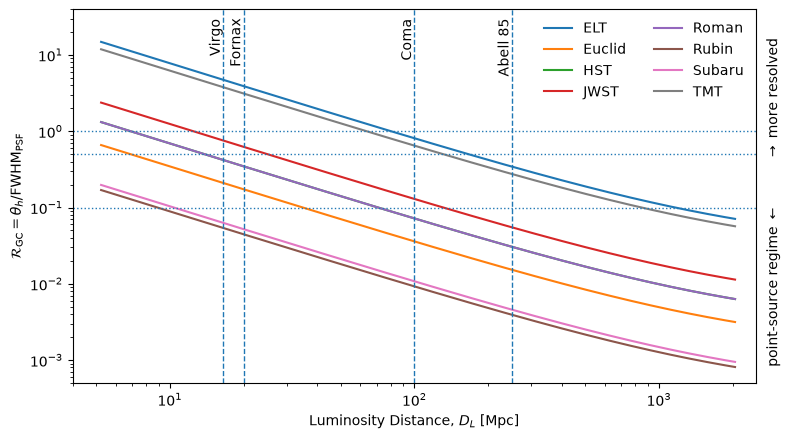

In [37]:

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.set_title("Globular Cluster Resolution with Distance")

for facility, sub in resolution.groupby("facility"):

    ax.plot(
        sub["D_L_mpc"],
        # sub["D_mpc"],
        sub["resolution_ratio"],
        label=facility
    )

ax.set_xlabel(r"Luminosity Distance, $D_L$ [Mpc]")
ax.set_ylabel(
    r"$\mathcal{R}_{\rm GC} = \theta_h / {\rm FWHM}_{\rm PSF}$"
)

ax.set_xscale("log")
ax.set_xlim(4, 2500)
ax.set_yscale("log")
ax.set_ylim(5e-4, 4e1)

# Illustrative resolution regimes
ax.axhline(1.0, ls=":", lw=1)
# ax.text(2000,0.5,r"more resolved $\uparrow$",va="bottom",ha="right")
ax.axhline(0.5, ls=":", lw=1)
# ax.text(1,0.085,r"point-source regime $\downarrow$",va="top",ha="left")
ax.axhline(0.1, ls=":", lw=1)

ax.text(
    1.015, 0.76,
    r"$\rightarrow$ more resolved",
    transform=ax.transAxes,
    rotation=90,
    va="center"
)

ax.text(
    1.015, 0.26,
    r"point-source regime $\leftarrow$",
    transform=ax.transAxes,
    rotation=90,
    va="center"
)

# Cluster distance markers
for name, D in {
    "Virgo": 16.5,
    "Fornax": 20.0,
    "Coma": 100.0,
    "Abell 85": 250.0,
}.items():

    ax.axvline(D, ls="--", lw=1)

    ax.text(
        D,
        30,
        name,
        rotation=90,
        va="top",
        ha="right"
    )

ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "gc_resolution_w_distance.png", bbox_inches='tight', format='png', dpi=200)

plt.show()


**Figure 3 — GC resolution with distance**

Angular-resolution regime for a representative globular cluster with half-light radius $r_h=3 \mathrm{pc}$ as a function of luminosity distance. The plotted quantity, $R_\mathrm{GC}=\theta_h/\mathrm{FWHM}_\mathrm{PSF}$, compares the apparent GC half-light radius with the characteristic point-spread-function width of each facility in the adopted observing band. Larger values correspond to increasingly resolved clusters, while small values approach the point-source regime. Horizontal dotted lines provide illustrative resolution boundaries, and vertical dashed lines mark Virgo, Fornax, Coma, and Abell 85. The figure highlights the transition from nearby structural studies to unresolved point-source surveys, and shows how future diffraction-limited extremely large telescopes extend the regime of measurable GC structure to substantially greater distances. The curves show a mild flattening at larger distances because GC angular size scales with angular-diameter distance, while the figure is plotted against luminosity distance for consistency with the other panels.

# Introduce smooth completeness transition

At the moment we have a hard-cutoff for the recovery fraction, 

$$f_\mathrm{rec}=\int_{-\infty}^{M_\mathrm{lim}(D)}\phi(M)dM$$

which assumes 100% detection brighter than the limit and 0% fainter. While this is simple, it is not realistic. A simple logistic completeness function is a good first diagnostic is

$$C(m)=\frac{1}{1+\exp{[\alpha(m-m_{50})]}}$$

where $m_{50}$ is the 50% completeness magnitude and $\alpha$ controls how sharp the turnover is.


In [38]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

SIGMA_GCLF = 1.40

def completeness_logistic(m, m50, alpha):
    return 1.0 / (1.0 + np.exp(alpha * (m - m50)))

def recovered_fraction_complete(
    distance_mpc,
    m50,
    M_to,
    sigma=SIGMA_GCLF,
    alpha=3.0
):
    mu = 5*np.log10(distance_mpc) + 25.0

    def integrand(M):
        phi = norm.pdf(M, loc=M_to, scale=sigma)
        m = M + mu
        return phi * completeness_logistic(m, m50, alpha)

    value, _ = quad(
        integrand,
        M_to - 8*sigma,
        M_to + 8*sigma
    )

    return value

In [39]:
alphas = [1.5, 3.0, 6.0]

In [40]:
dist = np.logspace(
    np.log10(5),
    np.log10(2000),
    500
)

rows = []

for _, row in reach.iterrows():

    for D in dist:

        f_hard = recovered_fraction(
            D,
            row["depth_5sigma_ab"],
            row["M_to_ab"]
        )

        f_smooth = recovered_fraction_complete(
            D,
            row["depth_5sigma_ab"],
            row["M_to_ab"],
            sigma=1.4,
            alpha=3.0
        )

        rows.append({
            "facility": row["facility"],
            "distance_mpc": D,
            "hard_fraction": f_hard,
            "smooth_fraction": f_smooth,
        })

comp_test = pd.DataFrame(rows)

## Plot a difference to hard-cutoff

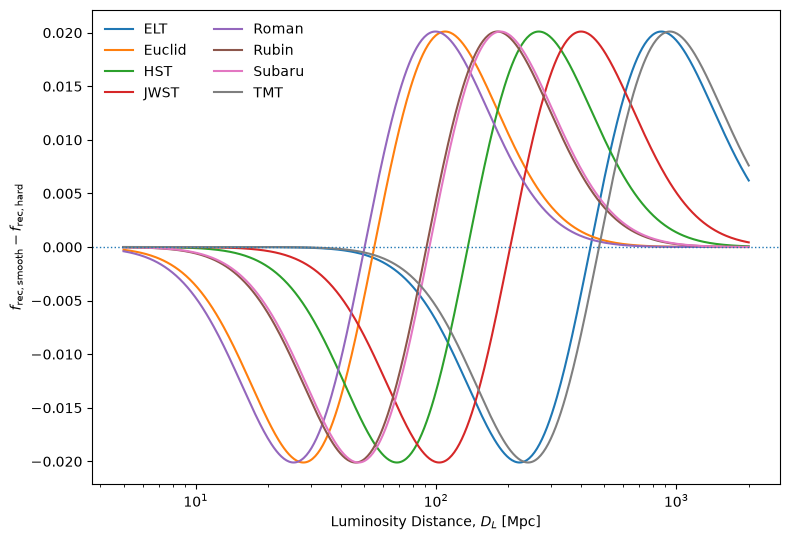

In [41]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for facility, sub in comp_test.groupby("facility"):

    ax.plot(
        sub["distance_mpc"],
        sub["smooth_fraction"] - sub["hard_fraction"],
        label=facility
    )

ax.set_xscale("log")
ax.axhline(0, ls=":", lw=1)

ax.set_xlabel(r"Luminosity Distance, $D_L$ [Mpc]")
ax.set_ylabel(
    r"$f_{\rm rec,smooth}-f_{\rm rec,hard}$"
)

ax.legend(
    frameon=False,
    ncol=2
)

plt.tight_layout()

In [42]:
from scipy.optimize import brentq

def reach_for_fraction_complete(
    target_fraction,
    m50,
    M_to,
    sigma=1.4,
    alpha=3.0,
    Dmin=0.1,
    Dmax=5000
):
    func = lambda D: (
        recovered_fraction_complete(
            D,
            m50,
            M_to,
            sigma=sigma,
            alpha=alpha
        )
        - target_fraction
    )

    return brentq(func, Dmin, Dmax)

In [43]:
for f in [0.1, 0.5, 0.9]:
    D = reach_for_fraction_complete(
        f,
        m50=row["depth_5sigma_ab"],
        M_to=row["M_to_ab"],
        sigma=1.4,
        alpha=3.0
    )


In [44]:
D

193.88266910999948

## Replot with continuous completeness

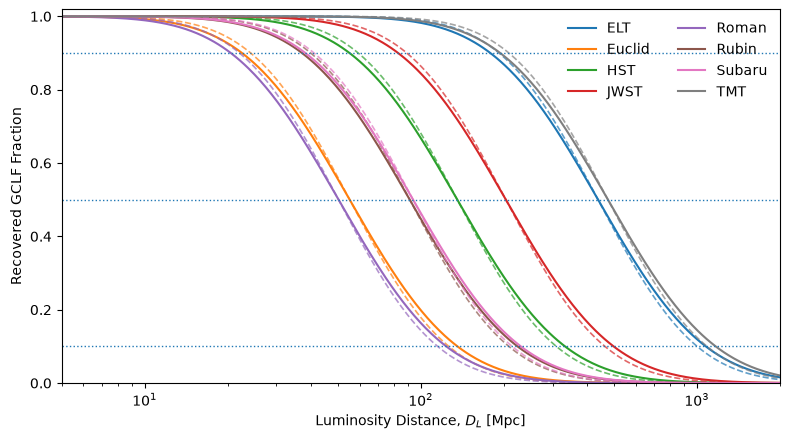

In [45]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for facility, sub in comp_test.groupby("facility"):

    # Smooth completeness
    line, = ax.plot(
        sub["distance_mpc"],
        sub["smooth_fraction"],
        label=facility
    )

    # Original hard-cutoff model, same colour
    ax.plot(
        sub["distance_mpc"],
        sub["hard_fraction"],
        ls="--",
        lw=1.2,
        color=line.get_color(),
        alpha=0.7
    )

ax.set_xscale("log")
ax.set_xlim(5, 2000)
ax.set_ylim(0, 1.02)

ax.set_xlabel(r"Luminosity Distance, $D_L$ [Mpc]")
ax.set_ylabel("Recovered GCLF Fraction")

for f in [0.1, 0.5, 0.9]:
    ax.axhline(f, ls=":", lw=1)

ax.legend(
    frameon=False,
    ncol=2
)

plt.tight_layout()
plt.show()

In [46]:
comp_test["delta_fraction"] = (
    comp_test["smooth_fraction"]
    - comp_test["hard_fraction"]
)

summary = (
    comp_test.groupby("facility")
    .agg(
        max_abs_delta=("delta_fraction", lambda x: np.max(np.abs(x))),
        rms_delta=("delta_fraction", lambda x: np.sqrt(np.mean(x**2))),
    )
    .reset_index()
)

summary

,facility,max_abs_delta,rms_delta
0,ELT,0.020106,0.010466
1,Euclid,0.020106,0.010516
2,HST,0.020106,0.010516
3,JWST,0.020106,0.010516
4,Roman,0.020106,0.010516
5,Rubin,0.020106,0.010516
6,Subaru,0.020106,0.010516
7,TMT,0.020106,0.010436


# Can this framework generate a science requirement?

## Define diagnostic thresholds

Define a few representative science cases and assign each a minimum useful GCLF recovery fraction. Not because those thresholds are sacred, but because it converts Figure 1 into something tangible.

| Science case                                         |       Illustrative requirement |
| ---------------------------------------------------- | -----------------------------: |
| Detect presence of a GC system / bright-tail mapping |       $(f_{\rm GCLF}\gtrsim0.1)$ |
| Large-scale spatial / ICGC mapping                   | $(f_{\rm GCLF}\gtrsim0.2{-}0.3)$ |
| Blue/red fraction or population comparisons          |       $(f_{\rm GCLF}\gtrsim0.5)$ |
| Robust total (N_{\rm GC}), (S_N), turnover/GCLF work | $(f_{\rm GCLF}\gtrsim0.8{-}0.9)$ |


In [47]:
science_cases = {
    "Bright-tail census": 0.10,
    "Environmental mapping": 0.25,
    "Population comparison": 0.50,
    "Representative GCLF": 0.90,
}

science_reach = []

for _, row in reach.iterrows():

    for science, fraction in science_cases.items():

        D = gclf_reach_mpc(
            row["depth_5sigma_ab"],
            row["M_to_ab"],
            fraction,
            sigma=SIGMA_GCLF
        )

        science_reach.append({
            "facility": row["facility"],
            "science_case": science,
            "fraction_required": fraction,
            "reach_mpc": D,
        })

science_reach = pd.DataFrame(science_reach)


In [48]:
science_reach_table = science_reach.pivot(
    index="facility",
    columns="science_case",
    values="reach_mpc"
)

science_reach_table


science_case,Bright-tail census,Environmental mapping,Population comparison,Representative GCLF
facility,,,,
ELT,1001.923212,677.418620,438.530698,191.940031
Euclid,126.284322,85.383141,55.273250,24.192489
HST,309.623873,209.342367,135.518941,59.315140
JWST,464.338227,313.947573,203.235701,88.954016
Roman,115.036176,77.778064,50.350061,22.037664
Rubin,208.369639,140.882526,91.201084,39.917705
Subaru,214.207384,144.829533,93.756201,41.036051
TMT,1087.944986,735.579516,476.181476,208.419360


## Create a cluster facing diagnostic


In [49]:
cluster_distances = {
    "Virgo": 16.5,
    "Fornax": 20.0,
    "Coma": 100.0,
    "Abell 85": 250.0,
}

cluster_rows = []

for cluster, D_target in cluster_distances.items():

    for facility, sub in grasp.groupby("facility"):

        idx = (sub["D_L_mpc"] - D_target).abs().idxmin()
        row = sub.loc[idx]

        cluster_rows.append({
            "cluster": cluster,
            "facility": facility,
            "D_L_mpc": row["D_L_mpc"],
            "D_A_mpc": row["D_A_mpc"],
            "z": row["z"],
            "gc_fraction": row["gc_fraction"],
            "fov_area_kpc2": row["fov_area_kpc2"],
            "gc_area_grasp_kpc2": row["gc_area_grasp_kpc2"],
        })

cluster_bench = pd.DataFrame(cluster_rows)

In [50]:
cluster_bench["reach_25"] = cluster_bench["gc_fraction"] >= 0.25
cluster_bench["reach_50"] = cluster_bench["gc_fraction"] >= 0.50
cluster_bench["reach_90"] = cluster_bench["gc_fraction"] >= 0.90


Show the full table sorted

In [51]:
cluster_bench[
    [
        "cluster",
        "facility",
        "gc_fraction",
        "fov_area_kpc2",
        "gc_area_grasp_kpc2",
        "reach_25",
        "reach_50",
        "reach_90",
    ]
].sort_values(
    ["cluster", "gc_area_grasp_kpc2"],
    ascending=[True, False]
)


,cluster,facility,gc_fraction,fov_area_kpc2,gc_area_grasp_kpc2,reach_25,reach_50,reach_90
29,Abell 85,Rubin,0.059201,1.475169e+08,8.733133e+06,False,False,False
30,Abell 85,Subaru,0.064424,2.715457e+07,1.749408e+06,False,False,False
25,Abell 85,Euclid,0.009687,8.297827e+06,8.038238e+04,False,False,False
28,Abell 85,Roman,0.006515,4.317943e+06,2.813160e+04,False,False,False
27,Abell 85,JWST,0.374992,4.140377e+04,1.552609e+04,True,False,False
26,Abell 85,HST,0.171760,4.838028e+04,8.309817e+03,False,False,False
24,Abell 85,ELT,0.808995,3.023767e+03,2.446211e+03,True,True,False
31,Abell 85,TMT,0.841818,1.370640e+03,1.153829e+03,True,True,False
21,Coma,Rubin,0.443469,2.675997e+07,1.186721e+07,True,False,False
22,Coma,Subaru,0.460441,4.925913e+06,2.268091e+06,True,False,False


Show just the GCLF fraction recovered for each of the clusters.

In [52]:
fraction_table = cluster_bench.pivot(
    index="facility",
    columns="cluster",
    values="gc_fraction"
)

fraction_table

cluster,Abell 85,Coma,Fornax,Virgo
facility,,,,
ELT,0.808995,0.989091,0.999999,1.000000
Euclid,0.009687,0.179071,0.942237,0.969824
HST,0.171760,0.681574,0.998486,0.999461
JWST,0.374992,0.864481,0.999837,0.999951
Roman,0.006515,0.143753,0.923518,0.958498
Rubin,0.059201,0.443469,0.990628,0.996034
Subaru,0.064424,0.460441,0.991654,0.996510
TMT,0.841818,0.992267,1.000000,1.000000


Show the physical FoV on a facility / cluster basis.

In [53]:
area_table = cluster_bench.pivot(
    index="facility",
    columns="cluster",
    values="fov_area_kpc2"
)

area_table

cluster,Abell 85,Coma,Fornax,Virgo
facility,,,,
ELT,3.023767e+03,5.485195e+02,2.363603e+01,16.014322
Euclid,8.297827e+06,1.505248e+06,6.486202e+04,43946.526363
HST,4.838028e+04,8.776312e+03,3.781764e+02,256.229147
JWST,4.140377e+04,7.510755e+03,3.236428e+02,219.280507
Roman,4.317943e+06,7.832865e+05,3.375227e+04,22868.470200
Rubin,1.475169e+08,2.675997e+07,1.153103e+06,781271.579794
Subaru,2.715457e+07,4.925913e+06,2.122605e+05,143814.671223
TMT,1.370640e+03,2.486378e+02,1.071395e+01,7.259114


## Cluster scatter plots



In [57]:
def pareto_front(df, x="gc_fraction", y="fov_area_kpc2"):

    keep = []

    for i, row in df.iterrows():

        dominated = (
            (df[x] >= row[x]) &
            (df[y] >= row[y]) &
            (
                (df[x] > row[x]) |
                (df[y] > row[y])
            )
        ).any()

        if not dominated:
            keep.append(i)

    return df.loc[keep].sort_values(x)

coma_pareto = pareto_front(coma)

coma_pareto[
    ["facility", "gc_fraction", "fov_area_kpc2"]
]

,facility,gc_fraction,fov_area_kpc2
21,Rubin,0.443469,2.675997e+07
22,Subaru,0.460441,4.925913e+06
18,HST,0.681574,8.776312e+03
19,JWST,0.864481,7.510755e+03
16,ELT,0.989091,5.485195e+02
23,TMT,0.992267,2.486378e+02


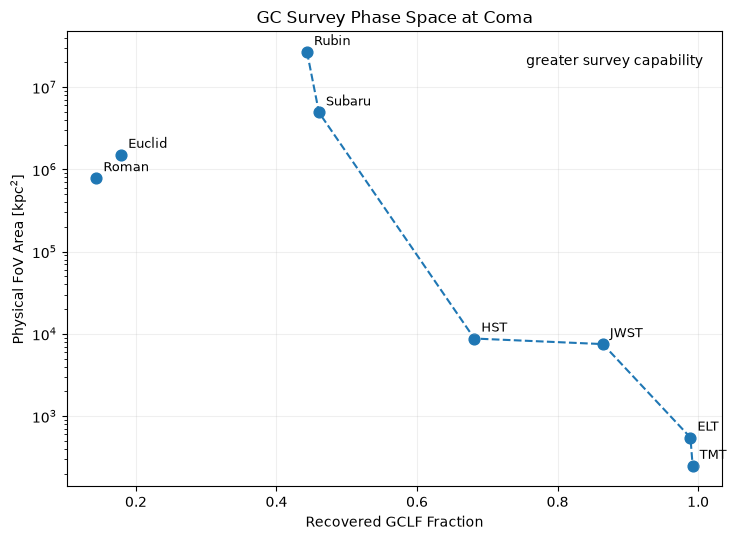

In [58]:
coma = cluster_bench[
    cluster_bench["cluster"] == "Coma"
].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    coma["gc_fraction"],
    coma["fov_area_kpc2"],
    s=60
)

ax.plot(
    coma_pareto["gc_fraction"],
    coma_pareto["fov_area_kpc2"],
    ls="--",
    lw=1.5
)

for _, row in coma.iterrows():
    ax.annotate(
        row["facility"],
        (row["gc_fraction"], row["fov_area_kpc2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.annotate(
    "greater survey capability",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=10
)

ax.set_yscale("log")

ax.set_xlabel("Recovered GCLF Fraction")
ax.set_ylabel(r"Physical FoV Area [kpc$^2$]")
ax.set_title("GC Survey Phase Space at Coma")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Investigate ICL-ICGC phase-space

Using only the facilities for which we have found a defensible LSB number right now.

In [59]:
lsb = pd.DataFrame([
    {
        "facility": "Subaru",
        "mu_lim_obs": 30.9,
        "sigma": 3,
        "area_arcsec2": 100.0,
        "status": "empirical"
    },
    {
        "facility": "Rubin",
        "mu_lim_obs": 30.3,
        "sigma": 3,
        "area_arcsec2": 100.0,
        "status": "predicted"
    },
    {
        "facility": "Euclid",
        "filter": "VIS",
        "mu_lim_obs": 29.5,
        "sigma": 3,
        "area_arcsec2": 100.0,
        "status": "predicted_wide",
    },
    {
        "facility": "Roman",
        "mu_lim_obs": 32.08,
        "sigma": 3,
        "area_arcsec2": 100.0,
        "status": "predicted_statistical"
    },
])

In [60]:
joint = cluster_bench.merge(
    lsb,
    on="facility",
    how="inner"
)

joint["mu_lim_rest"] = (
    joint["mu_lim_obs"]
    - 10*np.log10(1 + joint["z"])
)

In [61]:
coma_joint = joint[
    joint["cluster"] == "Coma"
].copy()


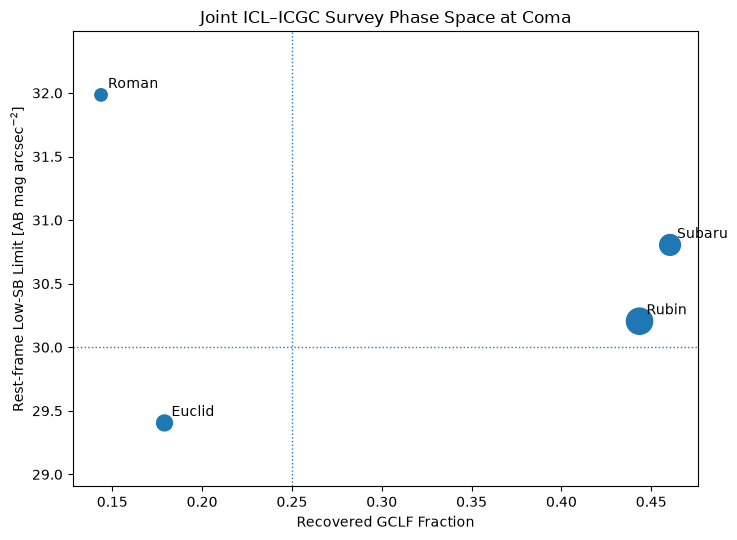

In [62]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

sizes = 80 + 180 * (
    np.log10(coma_joint["fov_area_kpc2"])
    - np.log10(coma_joint["fov_area_kpc2"]).min()
)

ax.scatter(
    coma_joint["gc_fraction"],
    coma_joint["mu_lim_rest"],
    s=sizes
)

ax.axhline(
    30.0,
    ls=":",
    lw=1
)

ax.axvline(
    0.25,
    ls=":",
    lw=1
)

for _, row in coma_joint.iterrows():
    ax.annotate(
        row["facility"],
        (row["gc_fraction"], row["mu_lim_rest"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_ylim(
    coma_joint["mu_lim_rest"].min() - 0.5,
    coma_joint["mu_lim_rest"].max() + 0.5
)

ax.set_xlabel("Recovered GCLF Fraction")
ax.set_ylabel(
    r"Rest-frame Low-SB Limit [AB mag arcsec$^{-2}$]"
)

ax.set_title("Joint ICL–ICGC Survey Phase Space at Coma")

plt.tight_layout()
plt.show()


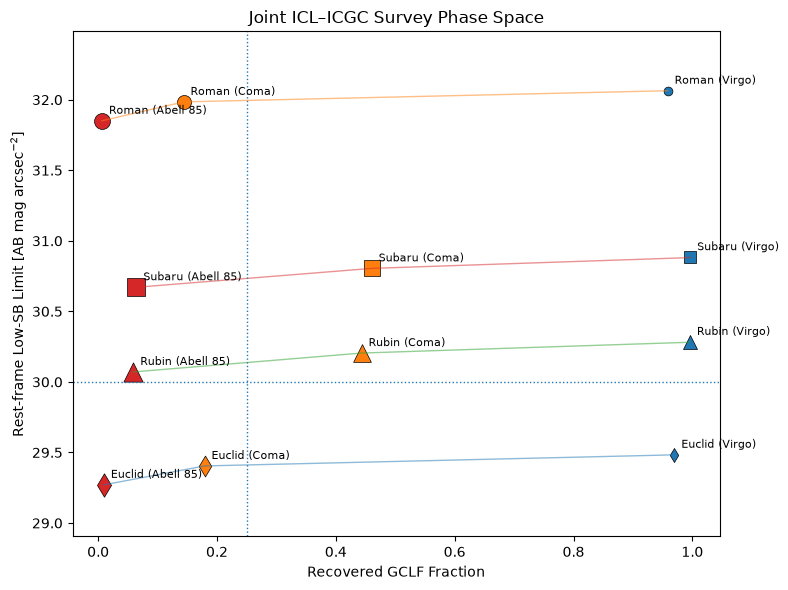

In [63]:
cluster_colors = {
    "Virgo": "tab:blue",
    "Fornax": "tab:green",
    "Coma": "tab:orange",
    "Abell 85": "tab:red",
}

facility_markers = {
    "Roman": "o",
    "Subaru": "s",
    "Rubin": "^",
    "Euclid": "d"
}

fig, ax = plt.subplots(figsize=(8, 6))
# print(joint)

for facility in joint["facility"].unique():
    sub = joint[joint["facility"] == facility].copy()

    # print(sub['cluster'])
    # if sub['cluster'].iloc[0]=='Fornax':
    #     print(sub) 
    # sort by distance if you want connected tracks
    sub = sub.sort_values("D_L_mpc")

    # optional connecting line
    ax.plot(
        sub["gc_fraction"],
        sub["mu_lim_rest"],
        lw=1,
        alpha=0.5
    )

    for _, row in sub.iterrows():
        if row['cluster']=='Fornax':
            continue
            
        size = 40 + 40 * (
            np.log10(row["fov_area_kpc2"]) -
            np.log10(joint["fov_area_kpc2"].min())
        )

        ax.scatter(
            row["gc_fraction"],
            row["mu_lim_rest"],
            s=size,
            color=cluster_colors[row["cluster"]],
            marker=facility_markers[row["facility"]],
            edgecolor="k",
            linewidth=0.5
        )

        ax.annotate(
            f"{row['facility']} ({row['cluster']})",
            (row["gc_fraction"], row["mu_lim_rest"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

ax.set_xlabel("Recovered GCLF Fraction")
ax.set_ylabel(r"Rest-frame Low-SB Limit [AB mag arcsec$^{-2}$]")
ax.set_title("Joint ICL–ICGC Survey Phase Space")

ax.axvline(0.25, ls=":", lw=1)
ax.axhline(30.0, ls=":", lw=1)
ax.set_ylim(
    coma_joint["mu_lim_rest"].min() - 0.5,
    coma_joint["mu_lim_rest"].max() + 0.5
)

plt.tight_layout()
plt.show()

## Maximum luminosity distance for $f_\mathrm{GCLF}>0.25$ GCLF and $\mu_\mathrm{lim}\geq30\ \mathrm{mag\ arcsec}^{-2}$

In [64]:
GC_MIN = 0.25
MU_MIN = 30.0

In [65]:
joint["joint_ok"] = (
    (joint["gc_fraction"] >= GC_MIN) &
    (joint["mu_lim_rest"] >= MU_MIN)
)


In [66]:
joint_sorted = joint.sort_values(
    ["facility", "D_L_mpc"]
)

joint_reach = (
    joint_sorted[joint_sorted["joint_ok"]]
    .groupby("facility", as_index=False)
    .tail(1)
    [
        [
            "facility",
            "D_L_mpc",
            "D_A_mpc",
            "z",
            "gc_fraction",
            "mu_lim_rest",
            "fov_area_kpc2",
        ]
    ]
    .rename(columns={
        "D_L_mpc": "D_L_joint_max_mpc",
        "D_A_mpc": "D_A_joint_max_mpc",
        "gc_fraction": "gc_fraction_at_limit",
        "mu_lim_rest": "mu_lim_rest_at_limit",
    })
    .reset_index(drop=True)
)

joint_reach


,facility,D_L_joint_max_mpc,D_A_joint_max_mpc,z,gc_fraction_at_limit,mu_lim_rest_at_limit,fov_area_kpc2
0,Roman,20.037390,19.857897,0.004509,0.923518,32.060460,3.375227e+04
1,Rubin,99.956402,95.662573,0.022196,0.443469,30.204657,2.675997e+07
2,Subaru,99.956402,95.662573,0.022196,0.460441,30.804657,4.925913e+06


In [67]:
joint_rows = []

for _, lsb_row in lsb.iterrows():

    facility = lsb_row["facility"]

    reach_row = reach[
        reach["facility"] == facility
    ].iloc[0]

    inst_row = inst[
        inst["facility"] == facility
    ].iloc[0]

    for z, D_L, D_A in zip(
        z_grid,
        D_L_grid,
        D_A_grid
    ):

        f_gc = recovered_fraction(
            D_L,
            reach_row["depth_5sigma_ab"],
            reach_row["M_to_ab"]
        )

        mu_rest = (
            lsb_row["mu_lim_obs"]
            - 10*np.log10(1 + z)
        )

        area = physical_fov_area_kpc2(
            D_A,
            inst_row["fov_area_deg2"]
        )

        joint_rows.append({
            "facility": facility,
            "z": z,
            "D_L_mpc": D_L,
            "D_A_mpc": D_A,
            "gc_fraction": f_gc,
            "mu_lim_rest": mu_rest,
            "fov_area_kpc2": area,
        })

joint_grid = pd.DataFrame(joint_rows)

In [68]:
joint_grid["joint_ok"] = (
    (joint_grid["gc_fraction"] >= GC_MIN) &
    (joint_grid["mu_lim_rest"] >= MU_MIN)
)


In [69]:
joint_reach = (
    joint_grid[joint_grid["joint_ok"]]
    .sort_values(["facility", "D_L_mpc"])
    .groupby("facility", as_index=False)
    .tail(1)
    [
        [
            "facility",
            "D_L_mpc",
            "D_A_mpc",
            "z",
            "gc_fraction",
            "mu_lim_rest",
            "fov_area_kpc2",
        ]
    ]
    .sort_values("D_L_mpc", ascending=False)
    .reset_index(drop=True)
)

joint_reach

,facility,D_L_mpc,D_A_mpc,z,gc_fraction,mu_lim_rest,fov_area_kpc2
0,Subaru,144.660754,135.856617,0.031894,0.250575,30.763650,9.934916e+06
1,Rubin,140.464966,132.147744,0.030989,0.251465,30.167459,5.106472e+07
2,Roman,77.764624,75.137596,0.017331,0.250085,32.005376,4.832269e+05


In [70]:
facilities = lsb["facility"].unique()

joint_summary = []

for facility in facilities:
    sub = joint_grid[joint_grid["facility"] == facility]

    ok = sub[sub["joint_ok"]]

    if len(ok) == 0:
        joint_summary.append({
            "facility": facility,
            "D_L_joint_max_mpc": np.nan,
            "status": "No joint window"
        })
    else:
        row = ok.loc[ok["D_L_mpc"].idxmax()]

        joint_summary.append({
            "facility": facility,
            "D_L_joint_max_mpc": row["D_L_mpc"],
            "status": "Joint window"
        })

joint_summary = pd.DataFrame(joint_summary)


In [71]:
for facility in facilities:
    sub = joint_grid[joint_grid["facility"] == facility].copy()

    gc_possible = (sub["gc_fraction"] >= GC_MIN).any()
    sb_possible = (sub["mu_lim_rest"] >= MU_MIN).any()

    print(
        facility,
        "GC:", gc_possible,
        "ICL:", sb_possible
    )


Subaru GC: True ICL: True
Rubin GC: True ICL: True
Euclid GC: True ICL: False
Roman GC: True ICL: True
